In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler

avocados = pd.read_csv('../data/avocado_clean.csv')
avocados.head()



,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,day,...,region_SOUTHCAROLINA,region_SOUTHCENTRAL,region_SOUTHEAST,region_SPOKANE,region_STLOUIS,region_SYRACUSE,region_TAMPA,region_TOTALUS,region_WEST,region_WESTTEXNEWMEXICO
0,-0.162848,-0.115021,-0.616377,0.369351,-0.286600,-0.504590,-0.260728,-0.671562,-0.646579,27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.110121,-0.183584,-0.744123,0.299899,-0.241293,-0.465177,-0.225881,-0.660104,-0.646579,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.217387,0.150551,-0.695336,0.612314,-0.049524,-0.533632,-0.287034,-0.645580,-0.646579,13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.821935,-0.024995,-0.590266,0.466825,-0.189427,-0.683308,-0.422779,-0.578466,-0.646579,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.294666,-0.215146,-0.645003,0.293577,-0.179170,-0.655747,-0.402128,-0.477375,-0.646579,29,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
avocados.info()

<class 'pandas.DataFrame'>
RangeIndex: 17934 entries, 0 to 17933
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   AveragePrice                17934 non-null  float64
 1   Total Volume                17934 non-null  float64
 2   4046                        17934 non-null  float64
 3   4225                        17934 non-null  float64
 4   4770                        17934 non-null  float64
 5   Total Bags                  17934 non-null  float64
 6   Small Bags                  17934 non-null  float64
 7   Large Bags                  17934 non-null  float64
 8   XLarge Bags                 17934 non-null  float64
 9   day                         17934 non-null  int64  
 10  week                        17934 non-null  int64  
 11  month                       17934 non-null  int64  
 12  type_ORGANIC                17934 non-null  float64
 13  region_ATLANTA              17934 non-null

### 1. importar datos y generar conjuntos de entrenamiento y testing

El dataset ya incluye variables temporales como `day`, `week` y `month`, por lo que no es necesario convertir una columna `Date`. Usamos estas columnas directamente para entrenar el modelo.

In [10]:
#avocados.describe()

# El dataset ya contiene las variables de tiempo como day/week/month,
# por lo que no existe una columna Date en avocado_clean.csv.
X = avocados.drop(columns=['AveragePrice'])
y = avocados['AveragePrice']
feature_names = X.columns

# Dividir datos en entrenamiento y prueba (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

avocados.info()

<class 'pandas.DataFrame'>
RangeIndex: 17934 entries, 0 to 17933
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   AveragePrice                17934 non-null  float64
 1   Total Volume                17934 non-null  float64
 2   4046                        17934 non-null  float64
 3   4225                        17934 non-null  float64
 4   4770                        17934 non-null  float64
 5   Total Bags                  17934 non-null  float64
 6   Small Bags                  17934 non-null  float64
 7   Large Bags                  17934 non-null  float64
 8   XLarge Bags                 17934 non-null  float64
 9   day                         17934 non-null  int64  
 10  week                        17934 non-null  int64  
 11  month                       17934 non-null  int64  
 12  type_ORGANIC                17934 non-null  float64
 13  region_ATLANTA              17934 non-null

### 2. Entrenamiento del modelo
se generan 3 variaciones con distintos parametros para comprobar numero de estimaddores y ratio de aprendizaje

In [11]:
GBa = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
GBa.fit(X_train, y_train)

GBb = GradientBoostingRegressor(n_estimators=250, learning_rate=0.05, max_depth=5, random_state=42)
GBb.fit(X_train, y_train)

GBc = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42)
GBc.fit(X_train, y_train)



,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

### 3. Resultado

Para establecer una comparacion, en el rpimer bloque  se ejecuta un modelo entrenado sin tener en cuenta la temporalidad (mes de compra), tomar en consideracion en que mes del año se realiza cada transaccion mejora la efectividad del modelo, posiblemente por factores del mercado propios de cada periodo del año.

In [ ]:
y_preda = GBa.predict(X_test)
y_predb = GBb.predict(X_test)
y_predc = GBc.predict(X_test)

print("Modelo GBa:")    
msea = mean_squared_error(y_test, y_preda)
r2a = r2_score(y_test, y_preda)
print(f"Mean Squared Error: {msea:.4f}")
print(f"R² Score: {r2a:.4f}")     

print("\nModelo GBb:")
mseb = mean_squared_error(y_test, y_predb)
r2b = r2_score(y_test, y_predb)
print(f"Mean Squared Error: {mseb:.4f}")
print(f"R² Score: {r2b:.4f}")    

print("\nModelo GBc:")
msec = mean_squared_error(y_test, y_predc)
r2c = r2_score(y_test, y_predc)
print(f"Mean Squared Error: {msec:.4f}")
print(f"R² Score: {r2c:.4f}")

Modelo GBa:
Mean Squared Error: 0.3198
R² Score: 0.6866

Modelo GBb:
Mean Squared Error: 0.2180
R² Score: 0.7864

Modelo GBc:
Mean Squared Error: 0.1779
R² Score: 0.8256


### Ajuste del modelo

- el numero de estimadores no tiene un impacto tan significativo si no se varia el learning rate, las estimaciones mejoran con un learning rate bajo para varios arboles y viceversa
- profundidad maxima, este tiene muchisimo mayor impacto, se evidencio mejora de hasta 10 puntos por cada nivel de profundidad, sin embargo para optimizar el entrenamiento y evitar el overfiting se establece en un maximo de 5 niveles
- 

### mejor ajuste

el modelo Gradient Booster c

```python

GBb = GradientBoostingRegressor(n_estimators=250, learning_rate=0.05, max_depth=5, random_state=42)

```
presenta un R² de 84.41, el modelo c tiene el doble de estimadores pero esto solo mejora la puntuacion en 3.3%, ademas como se mantiene el learnning rate bajo pero un numero alt de estimadores se reuce el overfiting, por esto aa pesar de duplicar los estimadores la ganancia no es tan significativa sin arriesgarse a que el modelo este memorizando los datos
   


## Comparativa de R²

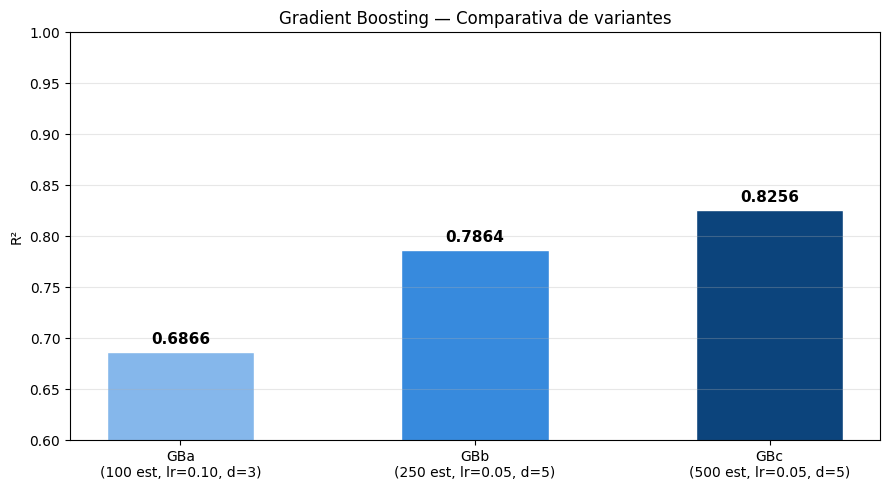

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

modelos   = ['GBa\n(100 est, lr=0.10, d=3)',
             'GBb\n(250 est, lr=0.05, d=5)',
             'GBc\n(500 est, lr=0.05, d=5)']
r2_scores = [r2a, r2b, r2c]
colores   = ['#85B7EB', '#378ADD', '#0C447C']

barras = ax.bar(modelos, r2_scores, color=colores, edgecolor='white', width=0.5)

for barra, valor in zip(barras, r2_scores):
    ax.text(barra.get_x() + barra.get_width()/2,
            barra.get_height() + 0.005,
            f'{valor:.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylim(0.6, 1.0)
ax.set_ylabel('R²')
ax.set_title('Gradient Boosting — Comparativa de variantes')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('gb_comparativa_variantes.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparativa valores reales vs predichos

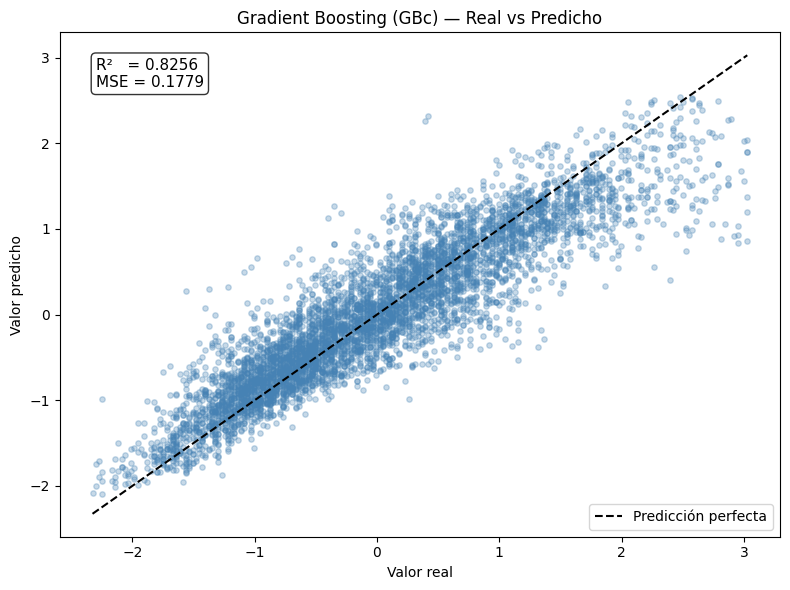

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_predc, alpha=0.3, s=15, color='steelblue')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'k--', linewidth=1.5, label='Predicción perfecta')

ax.text(0.05, 0.95,
        f'R²   = {r2c:.4f}\nMSE = {msec:.4f}',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title('Gradient Boosting (GBc) — Real vs Predicho')
ax.set_xlabel('Valor real')
ax.set_ylabel('Valor predicho')
ax.legend()
plt.tight_layout()
plt.savefig('gb_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()